## Eye data

In [1]:
from util import fisherztrans,stat_m_e,pair_test,sig,color_inv_alpha,rmanova_2factors
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
from faceprf_figure_function import set_figure,set_ax,myviolinplot_ind,myviolinplot_pair,myviolinplot_multi,myviolinplot_group
import pingouin

nsubj = 8
npos = 16
task = ['Digit Task','Face Task']
ntask = len(task)
ecc_bins = [[5,6,9,10],[1,2,4,7,8,11],[0,3,12,15]]

data_path = "../data/"

### gaze area

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_45184\3268568695.py:7: RuntimeWarning: Mean of empty slice
  bins_areas[...,ecc_i] = np.nanmean(np.nanmean(all_area[...,ecc_bins[ecc_i]],axis=-1),axis=-1)


Task:F(1,7)=4.7848, p-corr=0.0649,ng2=0.0826,eps=1.0
Ecc:F(2,14)=2.9454, p-corr=0.1193,ng2=0.0078,eps=0.6039
Task * Ecc:F(2,14)=4.2642, p-corr=0.0446,ng2=0.0065,eps=0.8568


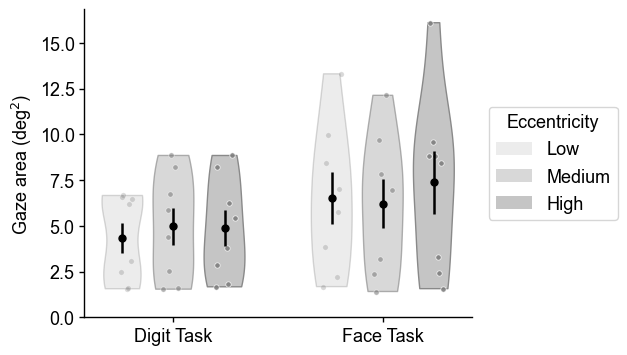

In [10]:
all_area = np.load(data_path+'contour_areas_session.npz',allow_pickle = True)['all_area'] # subject x task x session x position

colors = np.array([[0.5,0.5,0.5],[0.5,0.5,0.5]])

bins_areas = np.full([nsubj,ntask,len(ecc_bins)],np.nan)
for ecc_i in range(len(ecc_bins)):
    bins_areas[...,ecc_i] = np.nanmean(np.nanmean(all_area[...,ecc_bins[ecc_i]],axis=-1),axis=-1)
bins_areas[:,[0,1],:] = bins_areas[:,[1,0],:]

ecc_labels = ['Low', 'Medium', 'High']

# rm-anova for each subject : task x eccentricity
aov,df = rmanova_2factors(bins_areas,'Task','Ecc',task,ecc_labels,simpleprint=[0,1,2])

# plot
set_figure()
fig, ax = plt.subplots(1,1, figsize=(5, 4), gridspec_kw={'hspace':0.35,'wspace':0.4})
set_ax(ax)

myviolinplot_group(ax,bins_areas.transpose(0,2,1),'mean','sem',ecc_labels,task,colors,'Eccentricity')
ax.set_ylim(0, None)
ax.set_ylabel(r'Gaze area (deg$^2$)')

fig.savefig('../figures/figS13-gaze_areas_agg.pdf', bbox_inches='tight')


### gaze center

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_45184\2878530742.py:8: RuntimeWarning: Mean of empty slice
  bins_centerecc[...,ecc_i] = np.nanmean(np.nanmean(all_centerecc[...,ecc_bins[ecc_i]],axis=-1),axis=-1)


Task:F(1,7)=4.5646, p-corr=0.07,ng2=0.0427,eps=1.0
Ecc:F(2,14)=2.1642, p-corr=0.1772,ng2=0.0128,eps=0.6184
Task * Ecc:F(2,14)=0.3247, p-corr=0.6853,ng2=0.0004,eps=0.8104


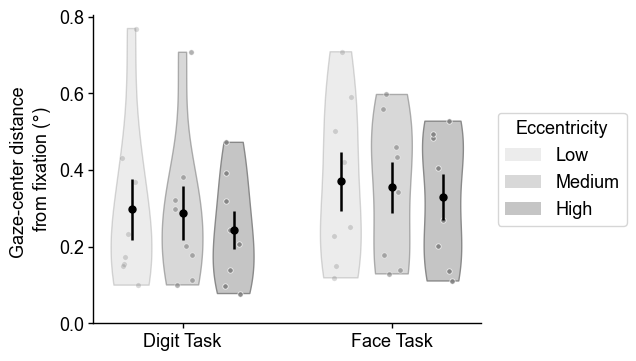

In [9]:
all_popt = np.load(data_path+'/fitting_params_session.npz',allow_pickle = True)['all_popt'] # 8sub x 2task x 16pos x 6param
all_centerecc = np.linalg.norm(all_popt[...,[1,2]],axis=-1)

colors = np.array([[0.5,0.5,0.5],[0.5,0.5,0.5]])

bins_centerecc = np.full([nsubj,ntask,len(ecc_bins)],np.nan)
for ecc_i in range(len(ecc_bins)):
    bins_centerecc[...,ecc_i] = np.nanmean(np.nanmean(all_centerecc[...,ecc_bins[ecc_i]],axis=-1),axis=-1)
bins_centerecc[:,[0,1],:] = bins_centerecc[:,[1,0],:]

ecc_labels = ['Low', 'Medium', 'High']

# rm-anova for each subject : task x eccentricity
aov,_ = rmanova_2factors(bins_centerecc,'Task','Ecc',task,ecc_labels,simpleprint=[0,1,2])

# plot
set_figure()
fig, ax = plt.subplots(1,1, figsize=(5, 4), gridspec_kw={'hspace':0.35,'wspace':0.4})
set_ax(ax)

myviolinplot_group(ax,bins_centerecc.transpose(0,2,1),'mean','sem',ecc_labels,task,colors,'Eccentricity')
ax.set_ylim(0, None)
ax.set_ylabel('Gaze-center distance \n'+r'from fixation ($\degree$)')

fig.savefig('../figures/figS13-gaze_centers_agg.pdf', bbox_inches='tight')


### correlation

p:[1.0, 1.0]


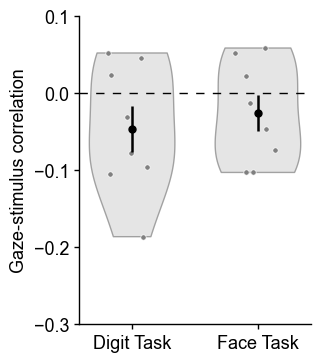

In [ ]:
all_corr = np.load(f'{data_path}/stim_eye_corr.npz',allow_pickle = True)['all_corr']
all_corr_fisherz = np.load(f'{data_path}/stim_eye_corr.npz',allow_pickle = True)['all_corr_fisherz']

all_corr_fisherz[:,[0,1],:] = all_corr_fisherz[:,[1,0],:]
all_corr_agg = np.nanmean(all_corr,axis=-1)
all_corr_fisherz_agg = np.nanmean(all_corr_fisherz,axis=-1)

import pingouin
# test
ps_all = np.ones([2])
ps = [pingouin.ttest(all_corr_fisherz_agg[:,task_i],0,paired = False)["p-val"].iloc[0] for task_i in range(2)]
print('p:{}'.format([round(p,4) for p in ps_all]))    

# plot
set_figure()
fig,ax = plt.subplots(1,1,figsize=(3,4),gridspec_kw={'wspace': 0.2})
set_ax(ax)
ylbls = 'Gaze-stimulus correlation'
ylims = [-0.3,0.1,0.1]
myviolinplot_ind(ax,all_corr_agg,"mean","sem",ps,[1])
ax.set_ylabel(ylbls)
ax.set_yticks(np.arange(ylims[0],ylims[1]*1.01,ylims[2]))
ax.set_ylim(ylims[:2])
ax.set_xticklabels(task)
ax.axhline(y=0,color=np.array([1,1,1])*0,linestyle='--',linewidth=1,dashes=(6,6))
fig.savefig('../figures/figS13-eye_correlation-agg.pdf', bbox_inches='tight')
